In [1]:
import pandas as pd
import numpy as np
import joblib
import re
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load resume dataset
resume_df = pd.read_csv("../data/processed/cleaned_resumes.csv")
# Load job dataset
jobs = pd.read_csv("../data/processed/cleaned_jobs.csv")
# Load saved TF-IDF models
resume_tfidf = joblib.load("../models/resume_tfidf.pkl")
job_tfidf = joblib.load("../models/job_tfidf.pkl")
job_matrix = joblib.load("../models/job_matrix.pkl")
print("Datasets and models loaded successfully!")
print("Number of resumes:", len(resume_df))
print("Number of jobs:", len(jobs))
print("Job matrix shape:", job_matrix.shape)

Datasets and models loaded successfully!
Number of resumes: 2483
Number of jobs: 61773
Job matrix shape: (61773, 10000)


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9+#]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
def get_skills_from_job(job_skills):
    skills = str(job_skills).split(",")
    skills = [clean_text(skill) for skill in skills]
    skills = [skill for skill in skills if skill]
    skills = list(dict.fromkeys(skills))
    return skills
def calculate_skill_match(resume_text, job_skills):
    resume_text = clean_text(resume_text)
    required_skills = get_skills_from_job(job_skills)
    if len(required_skills) == 0:
        return 0
    matched_skills = 0
    for skill in required_skills:
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, resume_text):
            matched_skills += 1
    skill_match = matched_skills / len(required_skills)
    return skill_match

In [4]:
test_resume = resume_df.iloc[0]["Resume_Text"]
test_job = jobs.iloc[0]["key_skills"]
skill_match = calculate_skill_match(test_resume, test_job)
print("Skill Match:", round(skill_match * 100, 2), "%")

Skill Match: 0.0 %


In [5]:
fit_data = []
sample_resumes = resume_df.sample(300, random_state=42)
for _, resume_row in sample_resumes.iterrows():
    resume_text = resume_row["Resume_Text"]
    resume_vector = job_tfidf.transform([resume_text])
    similarity_scores = cosine_similarity(
        resume_vector,
        job_matrix
    )[0]
    top_indices = similarity_scores.argsort()[-3:][::-1]
    for index in top_indices:
        job_row = jobs.iloc[index]
        text_similarity = similarity_scores[index]
        skill_match = calculate_skill_match(
            resume_text,
            job_row["key_skills"]
        )
        fit_data.append({
            "text_similarity": text_similarity,
            "skill_match": skill_match,
            "label": 1
        })
    random_indices = np.random.choice(
        len(jobs),
        size=3,
        replace=False
    )
    for index in random_indices:
        job_row = jobs.iloc[index]
        text_similarity = similarity_scores[index]
        skill_match = calculate_skill_match(
            resume_text,
            job_row["key_skills"]
        )
        fit_data.append({
            "text_similarity": text_similarity,
            "skill_match": skill_match,
            "label": 0
        })
fit_df = pd.DataFrame(fit_data)
print("Fit predictor dataset created!")
print("Number of training examples:", len(fit_df))
fit_df.head()

Fit predictor dataset created!
Number of training examples: 1800


,text_similarity,skill_match,label
0,0.287936,0.625,1
1,0.283874,0.250,1
2,0.275352,0.125,1
3,0.042314,0.000,0
4,0.003308,0.000,0


In [6]:
X = fit_df[["text_similarity", "skill_match"]]
y = fit_df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 1440
Testing examples: 360


In [7]:
fit_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
fit_model.fit(X_train, y_train)

print("Fit predictor trained successfully!")

Fit predictor trained successfully!


In [8]:
y_pred = fit_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Fit Predictor Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fit Predictor Accuracy: 99.44 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       180
           1       0.99      1.00      0.99       180

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[178   2]
 [  0 180]]


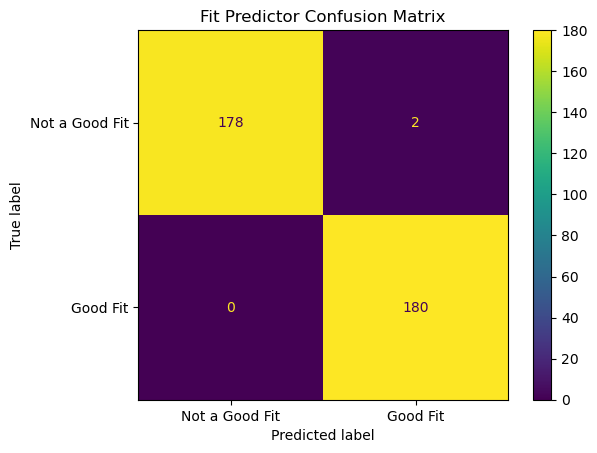

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not a Good Fit", "Good Fit"]
).plot()
plt.title("Fit Predictor Confusion Matrix")
plt.show()

In [11]:
import os
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(fit_model, "../models/fit_predictor.pkl")
print("Fit Predictor model saved successfully!")

Fit Predictor model saved successfully!
